Library

In [93]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [94]:
df = pd.read_csv(r'C:\Users\Pongo\Desktop\DBS project\LowCortisol\DataScientist\dataAI_cleaned.csv')
# Separate features and target variable
X = df.drop(columns=['tingkat_burnout'])
y = df['tingkat_burnout']

Encoding Kolom Teks Kategorikal

In [95]:
encoders = {}
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
    print(f"Encoded '{col}' with classes: {le.classes_}")

joblib.dump(encoders, 'all_encoders.pkl')

Encoded 'jenis_kelamin' with classes: ['Laki-laki' 'Perempuan']
Encoded 'pendidikan_terakhir' with classes: ['D3' 'S1' 'S2' 'S3' 'SD' 'SMA' 'SMP']
Encoded 'status_pernikahan' with classes: ['Belum Menikah' 'Cerai/Duda/Janda' 'Menikah']
Encoded 'departemen' with classes: ['Cs' 'Customer Service' 'Data' 'Design' 'Engineering' 'Finance' 'Ga' 'Hr'
 'Human Resource' 'Human Resources' 'Information Technology' 'It'
 'Keuangan' 'Lainnya' 'Legal' 'Logistik' 'Marketing' 'Mktg' 'Operasi'
 'Operasional' 'Operations' 'Ops' 'Pemasaran' 'Penjualan' 'Procurement'
 'Product' 'Research' 'Sales' 'Sdm' 'Support' 'Tech' 'Teknik']
Encoded 'jabatan' with classes: ['Akuntan' 'Backend Developer' 'Business Development' 'Customer Service'
 'Data Analyst' 'Data Scientist' 'Digital Marketing' 'Finance Analyst'
 'Finance Manager' 'Frontend Developer' 'Graphic Designer' 'Hr Manager'
 'Hr Specialist' 'Hr Staff' 'Intern' 'Junior Developer' 'Lainnya' 'Magang'
 'Marketing Manager' 'Marketing Staff' 'Operations Staff'
 '

C:\Users\Pongo\AppData\Local\Temp\ipykernel_24488\3122739783.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


['all_encoders.pkl']

Encoding

In [96]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(scaler, 'scaler.pkl')

print("Preprocessing completed and encoders/scaler saved.")
print("Preprocessed features (first 5 rows):")
print(X_scaled[:5])

Preprocessing completed and encoders/scaler saved.
Preprocessed features (first 5 rows):
[[ 1.14353484e+00  2.74609989e-01  6.24355355e-01 -1.01621099e+00
   7.88891921e-01 -8.74189428e-01 -1.16056757e+00  8.36828544e-01
   1.77258353e-01 -5.20606006e-01 -5.55406968e-01 -1.56913470e+00
  -5.78003125e-01 -1.59525330e+00 -3.83049410e-01  7.18551065e-01
  -2.61229813e-01  1.18890341e+00 -3.19404586e-01 -1.78139159e-01
  -1.10663638e-01  6.38972969e-01  1.64548483e-01 -8.38740319e-01
  -2.47331744e-01 -8.14271280e-01 -5.79250324e-01 -2.65326537e-01
   1.79768805e-01 -4.47523081e-01 -3.16835429e-02 -8.71809055e-01
   1.14761440e+00  1.71225008e+00  1.38385218e-01  2.09322051e+00
  -1.36293763e+00  2.56502964e-02  1.89479554e-01 -2.93521698e-01
  -2.45808542e+00  1.41543529e+00 -1.55781052e+00  1.00678023e+00
  -7.76432321e-01  1.00217170e+00]
 [ 1.14353484e+00 -1.04543240e+00 -2.65455704e-01 -1.01621099e+00
  -6.87928671e-01  1.59990919e+00 -9.55249344e-01 -5.46067621e-01
   8.09108359e-01 

In [97]:
print(f'Preprocessed features shape: {X_scaled.shape}')

Preprocessed features shape: (26139, 46)


SIMPAN

In [98]:
pd.DataFrame(X_scaled, columns=X.columns).to_csv('X_.csv', index=False)
y.to_csv('y_.csv', index=False)

cek distribusi

In [99]:
print(y.value_counts())

tingkat_burnout
1     18168
0      7379
4       115
3       111
2        83
5        75
7        65
6        56
8        39
10       27
9        21
Name: count, dtype: int64


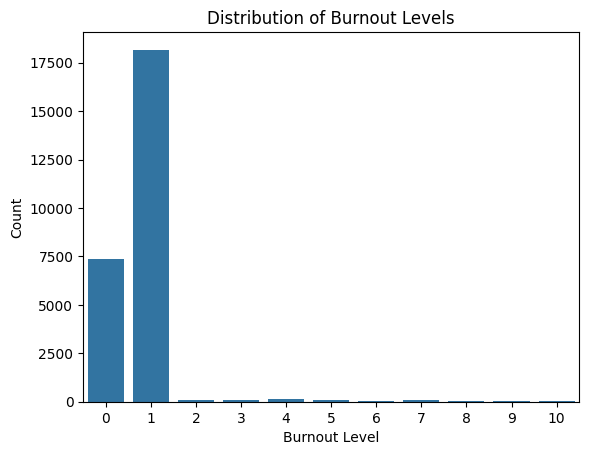

In [100]:
import seaborn as sns
sns.countplot(x=y)
plt.title('Distribution of Burnout Levels')
plt.xlabel('Burnout Level')
plt.ylabel('Count')
plt.show()

Hybrid Sampling

In [101]:
# 1. Kelompokkan 0-10 menjadi 3 kategori (Low, Moderate, High)
def categorize_burnout(level):
    if level <= 3:
        return 0 # Low
    elif level <= 7:
        return 1 # Moderate
    else:
        return 2 # High

df['target_tiga_kelas'] = df['tingkat_burnout'].apply(categorize_burnout)

# 2. Cek distribusi baru
print(df['target_tiga_kelas'].value_counts())

target_tiga_kelas
0    25741
1      311
2       87
Name: count, dtype: int64


TESTING WITH REAL DATA

In [102]:
encoders = joblib.load(r'C:\Users\Pongo\Desktop\DBS project\LowCortisol\AI\all_encoders.pkl')
scaler = joblib.load(r'C:\Users\Pongo\Desktop\DBS project\LowCortisol\AI\scaler.pkl')

In [103]:
#TESTING DATA 100 ASLI
df_real_test = df.sample(n=100, random_state=42)
X_real = df_real_test.drop(columns=['tingkat_burnout', 'target_tiga_kelas'])


In [104]:
X_real_encoded = X_real.copy()
for col, le in encoders.items():
    if col in X_real_encoded.columns:
        # Kita gunakan le.transform, BUKAN fit_transform
        X_real_encoded[col] = le.transform(X_real_encoded[col].astype(str))

In [105]:
X_real_scaled = scaler.transform(X_real_encoded)

In [106]:
# 1. Pastikan target adalah yang sudah di-binning
y_new = df_real_test['target_tiga_kelas']

# 2. Definisikan Pipeline
under = RandomUnderSampler(sampling_strategy={0: 5000}) # Low kita kurangi jadi 5000
over = SMOTE(sampling_strategy="auto") # Moderate & High akan naik jadi 5000 secara otomatis

steps = [('u', under), ('o', over)]
pipeline = Pipeline(steps=steps)

# 3. Eksekusi (Gunakan y_new!)
X_resampled, y_resampled = pipeline.fit_resample(X_real_scaled, y_new)

print(f'Resampled features shape: {X_resampled.shape}')
print(pd.Series(y_resampled).value_counts())

ValueError: The target 'y' needs to have more than 1 class. Got 1 class instead

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)
print(f'Train features shape: {X_train.shape}, Train target shape: {y_train.shape}')

Train features shape: (12000, 46), Train target shape: (12000,)


Membangun Arsitektur ANN

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    # input layer
    layers.Input(shape=(X_train.shape[1],)),
    #hidden layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    # output layer
    layers.Dense(3, activation='softmax')  # Output layer untuk 3 kelas
])

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         3,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,187 (20.26 KB)

 Trainable params: 5,187 (20.26 KB)

 Non-trainable params: 0 (0.00 B)

Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5135 - loss: 0.9651 - val_accuracy: 0.7157 - val_loss: 0.7390
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6944 - loss: 0.6977 - val_accuracy: 0.8280 - val_loss: 0.4907
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7725 - loss: 0.5295 - val_accuracy: 0.8610 - val_loss: 0.3727
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8110 - loss: 0.4414 - val_accuracy: 0.8860 - val_loss: 0.3133
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8448 - loss: 0.3746 - val_accuracy: 0.9007 - val_loss: 0.2663
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8632 - loss: 0.3283 - val_accuracy: 0.9167 - val_loss: 0.2310
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8788 - loss: 0.2972 - val_accuracy: 0.9243 - val_loss: 0.2121
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8922 - loss: 0.2632 - val_accuracy: 0.

checking

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Prediksi data testing
y_pred = model.predict(X_real_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)

# 2. Tampilkan Classification Report
# Ini akan menunjukkan performa di tiap kelas (Low, Moderate, High)
print("Classification Report:")
print(classification_report(y_new, y_pred_classes, target_names=['Low', 'Moderate', 'High']))

# 3. Tampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Moderate', 'High'], yticklabels=['Low', 'Moderate', 'High'])
plt.xlabel('Prediksi')
plt.ylabel('Kenyataan')
plt.title('Confusion Matrix - Evaluasi Model')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Classification Report:


ValueError: Found input variables with inconsistent numbers of samples: [26139, 100]

result evaluations

In [ ]:
# evaluasi di data testing
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"akurasi model di data uji: {accuracy:.4f}")

# simpen model final
model.save('burnout_model.h5')
print("Model saved as 'burnout_model.h5'")

akurasi model di data uji: 0.9840
Model saved as 'burnout_model.h5'
